# 04 — Analyse de performance approfondie

**Projet** : Stratégie quantitative momentum sur le STOXX Europe 600  
**Auteur** : ISLEYEN Volkan
**Date** : Mai 2026

## Objectif

Approfondir et stress-tester la stratégie momentum backtestée au notebook 03, à travers trois analyses complémentaires.

## Analyses menées

1. **Comparaison au facteur WML académique** (Ken French) : vérifier que la stratégie capture bien le facteur momentum reconnu par la littérature, via corrélation et régression.

2. **Test de robustesse sur la fenêtre de calcul** : comparer les fenêtres momentum 3 mois, 6 mois et 12 mois pour vérifier que le résultat ne dépend pas d'un choix de paramètre arbitraire (risque de data snooping).

3. **Décomposition de la performance par année** : examiner si la surperformance est régulière ou concentrée sur quelques périodes.

## Données en entrée

- `data/processed/prices_clean.csv` — cours des titres
- `data/processed/returns_daily.csv` — rendements quotidiens
- `data/processed/wml_factor.csv` — facteur momentum académique
- `data/raw/benchmark_stoxx600.csv` — benchmark

In [2]:
# Librairies
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from pathlib import Path
import warnings

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
plt.style.use('seaborn-v0_8-darkgrid')

# Chemins
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"
DATA_RAW = PROJECT_ROOT / "data" / "raw"
FIGURES = PROJECT_ROOT / "output" / "figures"
TABLES = PROJECT_ROOT / "output" / "tables"

for d in [FIGURES, TABLES]:
    d.mkdir(parents=True, exist_ok=True)

# Chargement des données
prices = pd.read_csv(DATA_PROCESSED / "prices_clean.csv", index_col=0, parse_dates=True)
returns = pd.read_csv(DATA_PROCESSED / "returns_daily.csv", index_col=0, parse_dates=True)
weights = pd.read_csv(DATA_PROCESSED / "weights_momentum.csv", index_col=0, parse_dates=True)
wml = pd.read_csv(DATA_PROCESSED / "wml_factor.csv", index_col=0, parse_dates=True)
benchmark = pd.read_csv(DATA_RAW / "benchmark_stoxx600.csv", index_col=0, parse_dates=True)

# Reconstruire les rendements du portefeuille (comme au notebook 03)
portfolio_returns = (weights.shift(1) * returns).sum(axis=1)
portfolio_returns = portfolio_returns[portfolio_returns.index >= "2016-01-01"]

print("Données chargées")
print(f"Prix : {prices.shape}")
print(f"Rendements portefeuille : {len(portfolio_returns)} jours")
print(f"Facteur WML : {wml.shape}")
print(f"Période portefeuille : {portfolio_returns.index.min().date()} → {portfolio_returns.index.max().date()}")

Données chargées
Prix : (2586, 577)
Rendements portefeuille : 2325 jours
Facteur WML : (2609, 1)
Période portefeuille : 2016-01-04 → 2024-12-30


In [5]:
# Comparaison au facteur momentum académique WML (Ken French)

# Le WML est en POURCENTAGE, on le convertit en décimal
wml_returns = wml["WML"]/100

# Aligner les deux séries sur les dates communes
aligned = pd.DataFrame({
    "strategy" : portfolio_returns,
    "wml" : wml_returns
}).dropna()

print(f"Oberservations alignées : {len(aligned)}")
print(f"Période : {aligned.index.min().date()} → {aligned.index.max().date()}")

# Corrélation
correlation = aligned["strategy"].corr(aligned["wml"])
print(f"\n--- Corrélation ---")
print(f"Corrélation stratégie / WML : {correlation:.3f}")

# Statistique comparatives
print(f"\n--- Comparaison des rendements quotidiens moyens ---")
print(f"Stratégie : {aligned['strategy'].mean()*100:.4f}% / jour")
print(f"WML       : {aligned['wml'].mean()*100:.4f}% / jour")
print(f"\n--- Volatilité quotidienne ---")
print(f"Stratégie : {aligned['strategy'].std()*100:.4f}%")
print(f"WML       : {aligned['wml'].std()*100:.4f}%")


Oberservations alignées : 2325
Période : 2016-01-04 → 2024-12-30

--- Corrélation ---
Corrélation stratégie / WML : 0.099

--- Comparaison des rendements quotidiens moyens ---
Stratégie : 0.0518% / jour
WML       : 0.0292% / jour

--- Volatilité quotidienne ---
Stratégie : 1.0146%
WML       : 0.7614%


In [6]:
# Régression : rendements stratégie = alpha + beta_mkt * marché + beta_wml * WML
# Objectif : isoler l'exposition au momentum APRÈS contrôle du risque de marché

# Rendements du benchmark (marché)
bench_returns = benchmark["stoxx600_etf"].pct_change()

# Aligner les trois séries
reg_data = pd.DataFrame({
    "strategy": portfolio_returns,
    "market": bench_returns,
    "wml": wml_returns
}).dropna()

print(f"Observations : {len(reg_data)}\n")

# Variables explicatives : marché + WML
X = reg_data[["market", "wml"]]
X = sm.add_constant(X)
y = reg_data["strategy"]

# Régression avec erreurs robustes HC3
model = sm.OLS(y, X).fit(cov_type="HC3")

print(model.summary())

Observations : 2287

                            OLS Regression Results                            
Dep. Variable:               strategy   R-squared:                       0.860
Model:                            OLS   Adj. R-squared:                  0.860
Method:                 Least Squares   F-statistic:                     2883.
Date:                Thu, 04 Jun 2026   Prob (F-statistic):               0.00
Time:                        13:54:45   Log-Likelihood:                 9487.7
No. Observations:                2287   AIC:                        -1.897e+04
Df Residuals:                    2284   BIC:                        -1.895e+04
Df Model:                           2                                         
Covariance Type:                  HC3                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const       9.373e-05   8.15e-0

### Comparaison au facteur momentum académique (WML)

**Une corrélation brute trompeuse**  
La corrélation simple entre les rendements de la stratégie et le facteur WML de Ken French est faible (0,099). Ce chiffre est toutefois trompeur : la stratégie étant long-only, elle est dominée par le risque de marché, tandis que le WML est un facteur long-short quasi neutre au marché. La corrélation brute mélange ces deux dimensions.

**Une régression révélatrice**  
La régression des rendements de la stratégie sur le marché et le WML conjointement clarifie la relation :

$$r_{\text{strat}} = \alpha + \beta_{\text{mkt}} \, r_{\text{mkt}} + \beta_{\text{wml}} \, r_{\text{wml}} + \varepsilon$$

- **Beta marché = 0,956** (p < 0,001) : exposition au marché proche de 1, conforme à une stratégie long-only
- **Beta WML = 0,469** (p < 0,001) : exposition positive et hautement significative au facteur momentum, une fois le marché contrôlé
- **Alpha = 0,009 %/jour, non significatif** (p = 0,25)
- **R² = 0,86** : le marché et le momentum expliquent 86 % de la variance des rendements de la stratégie

**Interprétation**  
Une fois le risque de marché neutralisé, la stratégie présente une exposition significative au facteur momentum académique : elle capture donc bien le phénomène documenté par la littérature, et non un artefact des données. 

L'alpha non significatif est un résultat cohérent et attendu : il indique que la surperformance de la stratégie s'explique entièrement par son exposition au facteur momentum, sans rendement résiduel inexpliqué. Autrement dit, la stratégie ne fait pas « mieux que le momentum » — elle *est* une mise en œuvre du momentum, et en capture la prime de façon efficace.

In [7]:
# Fonction de backtest complète, paramétrée par la fenêtre momentum
# Réutilise toute la logique des notebooks 02 et 03

def backtest_momentum(prices, returns, lookback, skip=21, n_quintiles=5,
                      transaction_cost=0.0015, start_backtest="2016-01-01"):
    """
    Backtest complet d'une stratégie momentum.
    
    lookback : fenêtre momentum en jours (ex: 63=3M, 126=6M, 252=12M)
    skip     : nombre de jours sautés à la fin (réversion court terme)
    
    Retourne : dict avec rendements nets, métriques clés
    """
    # 1. Dates de rebalancement (fin de mois)
    month_ends = prices.resample("ME").last().index
    rebalance_dates = []
    for me in month_ends:
        valid = prices.index[prices.index <= me]
        if len(valid) > 0:
            rebalance_dates.append(valid[-1])
    rebalance_dates = pd.DatetimeIndex(rebalance_dates).unique()
    
    # 2. Signal momentum + quintiles + poids
    weights = pd.DataFrame(0.0, index=prices.index, columns=prices.columns)
    reb_with_signal = []
    
    for reb_date in rebalance_dates:
        pos = prices.index.get_loc(reb_date)
        if pos < lookback:
            continue
        mom = (prices.iloc[pos - skip] / prices.iloc[pos - lookback]) - 1
        signals = mom.dropna()
        if len(signals) < n_quintiles * 5:
            continue
        quintiles = pd.qcut(signals, n_quintiles, labels=range(1, n_quintiles + 1))
        winners = quintiles[quintiles == n_quintiles].index.tolist()
        reb_with_signal.append((reb_date, winners))
    
    # 3. Remplir la matrice de poids
    for i, (reb_date, winners) in enumerate(reb_with_signal):
        w = 1.0 / len(winners)
        start_apply = reb_date
        end_apply = reb_with_signal[i+1][0] if i+1 < len(reb_with_signal) else prices.index[-1]
        mask = (prices.index > start_apply) & (prices.index <= end_apply)
        weights.loc[mask, winners] = w
    
    # 4. Rendements bruts
    port_ret = (weights.shift(1) * returns).sum(axis=1)
    port_ret = port_ret[port_ret.index >= start_backtest]
    
    # 5. Turnover et coûts
    daily_costs = pd.Series(0.0, index=port_ret.index)
    for i in range(1, len(reb_with_signal)):
        reb_prev_date, prev_w = reb_with_signal[i-1]
        reb_curr_date, curr_w = reb_with_signal[i]
        pos_prev = weights.index[weights.index > reb_prev_date]
        pos_curr = weights.index[weights.index > reb_curr_date]
        if len(pos_prev) == 0 or len(pos_curr) == 0:
            continue
        turnover = 0.5 * (weights.loc[pos_curr[0]] - weights.loc[pos_prev[0]]).abs().sum()
        apply_dates = port_ret.index[port_ret.index > reb_curr_date]
        if len(apply_dates) > 0:
            daily_costs.loc[apply_dates[0]] = turnover * transaction_cost * 2
    
    port_ret_net = port_ret - daily_costs
    
    # 6. Métriques
    n_years = len(port_ret_net) / 252
    total_ret = (1 + port_ret_net).prod() - 1
    ann_ret = (1 + total_ret) ** (1/n_years) - 1
    ann_vol = port_ret_net.std() * np.sqrt(252)
    sharpe = (port_ret_net.mean() / port_ret_net.std()) * np.sqrt(252)
    cum = (1 + port_ret_net).cumprod()
    max_dd = ((cum - cum.cummax()) / cum.cummax()).min()
    
    return {
        "returns_net": port_ret_net,
        "ann_return": ann_ret,
        "ann_vol": ann_vol,
        "sharpe": sharpe,
        "max_dd": max_dd,
        "total_return": total_ret,
    }

print("Fonction de backtest définie.")
print("On peut maintenant tester n'importe quelle fenêtre momentum facilement.")

Fonction de backtest définie.
On peut maintenant tester n'importe quelle fenêtre momentum facilement.


In [8]:
# Test de robustesse : comparer les fenêtres momentum 3M, 6M, 12M
# 63 jours ≈ 3 mois, 126 ≈ 6 mois, 252 ≈ 12 mois

windows = {
    "3 mois": 63,
    "6 mois": 126,
    "12 mois": 252,
}

print("Backtest des trois fenêtres momentum...\n")

results = {}
for name, lookback in windows.items():
    print(f"  Calcul fenêtre {name} ({lookback} jours)...")
    results[name] = backtest_momentum(prices, returns, lookback=lookback)

# Tableau comparatif
comparison = pd.DataFrame({
    name: {
        "Rendement annualisé": f"{res['ann_return']*100:.2f}%",
        "Volatilité annualisée": f"{res['ann_vol']*100:.2f}%",
        "Ratio de Sharpe": f"{res['sharpe']:.3f}",
        "Max Drawdown": f"{res['max_dd']*100:.2f}%",
        "Rendement total": f"{res['total_return']*100:.1f}%",
    }
    for name, res in results.items()
}).T

# Ajouter le benchmark pour référence
bench_ret = benchmark["stoxx600_etf"].pct_change()
bench_ret = bench_ret[(bench_ret.index >= "2016-01-01") & (bench_ret.index <= "2024-12-31")].dropna()
n_years_b = len(bench_ret) / 252
bench_total = (1 + bench_ret).prod() - 1
bench_ann = (1 + bench_total) ** (1/n_years_b) - 1
bench_sharpe = (bench_ret.mean() / bench_ret.std()) * np.sqrt(252)
bench_cum = (1 + bench_ret).cumprod()
bench_dd = ((bench_cum - bench_cum.cummax()) / bench_cum.cummax()).min()

comparison.loc["STOXX 600 (benchmark)"] = {
    "Rendement annualisé": f"{bench_ann*100:.2f}%",
    "Volatilité annualisée": f"{bench_ret.std()*np.sqrt(252)*100:.2f}%",
    "Ratio de Sharpe": f"{bench_sharpe:.3f}",
    "Max Drawdown": f"{bench_dd*100:.2f}%",
    "Rendement total": f"{bench_total*100:.1f}%",
}

print("\n" + "=" * 80)
print("COMPARAISON DES FENÊTRES MOMENTUM (2016-2024, net de coûts)")
print("=" * 80)
print(comparison.to_string())

comparison.to_csv(TABLES / "04_windows_comparison.csv")
print(f"\nTableau sauvegardé : {TABLES / '04_windows_comparison.csv'}")

Backtest des trois fenêtres momentum...

  Calcul fenêtre 3 mois (63 jours)...
  Calcul fenêtre 6 mois (126 jours)...
  Calcul fenêtre 12 mois (252 jours)...

COMPARAISON DES FENÊTRES MOMENTUM (2016-2024, net de coûts)
                      Rendement annualisé Volatilité annualisée Ratio de Sharpe Max Drawdown Rendement total
3 mois                              9.10%                16.16%           0.621      -34.77%          123.4%
6 mois                             11.81%                16.11%           0.774      -39.74%          180.1%
12 mois                            11.34%                16.10%           0.749      -36.81%          169.4%
STOXX 600 (benchmark)               6.46%                16.24%           0.467      -35.70%           76.5%

Tableau sauvegardé : C:\Users\volka\Documents\momentum-strategy-stoxx600\output\tables\04_windows_comparison.csv


### Test de robustesse : sensibilité à la fenêtre de calcul

Pour écarter le risque de data snooping (sélection a posteriori d'un paramètre favorable), la stratégie est testée sur trois fenêtres de calcul du momentum : 
3, 6 et 12 mois.

**Les trois fenêtres surperforment le marché**  
Quelle que soit la fenêtre retenue, la stratégie bat le benchmark STOXX 600 
(Sharpe de 0,467) :

| Fenêtre | Rendement annualisé | Sharpe | Max Drawdown |
|---------|---------------------|--------|--------------|
| 3 mois  | 9,10 %  | 0,621 | −34,8 % |
| 6 mois  | 11,81 % | 0,774 | −39,7 % |
| 12 mois | 11,34 % | 0,749 | −36,8 % |

Ce résultat constitue un test de robustesse important : la surperformance ne dépend pas d'un choix de paramètre particulier, ce qui réduit le risque que le résultat soit le fruit d'une optimisation a posteriori.

**Une hiérarchie conforme à la littérature**  
Les fenêtres moyennes (6 et 12 mois) dominent la fenêtre courte (3 mois). Ce classement est cohérent avec la littérature académique : les fenêtres de 6 à 12 mois constituent le « sweet spot » du momentum, tandis que la fenêtre de 3 mois est plus faible car elle se rapproche de la zone de réversion à court terme, où les titres récemment performants tendent à corriger.

**Arbitrage risque-rendement**  
La fenêtre de 6 mois offre le meilleur ratio de Sharpe mais le drawdown le plus sévère (−39,7 %). La fenêtre de 12 mois retenue dans l'analyse principale offre un compromis équilibré : un Sharpe quasi équivalent (0,749) pour un risque de 
baisse moindre. Le choix initial de 12 mois apparaît donc justifié.

In [10]:
# Décomposition de la performance par année civile : stratégie vs benchmark

# On utilise les rendements nets de la stratégie 12 mois (notre stratégie principale)
strategy_net = results["12 mois"]["returns_net"]

# Rendements du benchmark alignés
bench_ret = benchmark["stoxx600_etf"].pct_change()
bench_ret = bench_ret[(bench_ret.index >= "2016-01-01") & (bench_ret.index <= "2024-12-31")].dropna()

# Calculer le rendement par année civile (rendement composé)
def annual_returns(daily_returns):
    return daily_returns.groupby(daily_returns.index.year).apply(lambda x: (1 + x).prod() - 1)

strat_annual = annual_returns(strategy_net)
bench_annual = annual_returns(bench_ret)

# Tableau comparatif
annual_comp = pd.DataFrame({
    "Stratégie momentum": strat_annual * 100,
    "STOXX 600": bench_annual * 100,
})
annual_comp["Surperformance"] = annual_comp["Stratégie momentum"] - annual_comp["STOXX 600"]
annual_comp["Stratégie gagne ?"] = annual_comp["Surperformance"].apply(lambda x: "√ Oui" if x > 0 else "X Non")

print("=" * 70)
print("PERFORMANCE PAR ANNÉE CIVILE (rendements en %, net de coûts)")
print("=" * 70)
print(annual_comp.round(2).to_string())

# Statistiques de régularité
n_years = len(annual_comp)
n_wins = (annual_comp["Surperformance"] > 0).sum()
print(f"\n--- Régularité de la surperformance ---")
print(f"Années où la stratégie bat le marché : {n_wins} / {n_years}")
print(f"Taux de réussite annuel : {n_wins/n_years*100:.0f}%")

annual_comp.to_csv(TABLES / "04_annual_performance.csv")
print(f"\nTableau sauvegardé : {TABLES / '04_annual_performance.csv'}")

PERFORMANCE PAR ANNÉE CIVILE (rendements en %, net de coûts)
      Stratégie momentum  STOXX 600  Surperformance Stratégie gagne ?
Date                                                                 
2016               12.47       1.56           10.90             √ Oui
2017               20.58      10.67            9.91             √ Oui
2018               -6.28     -10.99            4.71             √ Oui
2019               33.19      28.41            4.78             √ Oui
2020               11.04      -1.80           12.84             √ Oui
2021               21.55      24.57           -3.02             X Non
2022              -16.19     -10.33           -5.85             X Non
2023               12.56      15.46           -2.90             X Non
2024               25.01       8.50           16.50             √ Oui

--- Régularité de la surperformance ---
Années où la stratégie bat le marché : 6 / 9
Taux de réussite annuel : 67%

Tableau sauvegardé : C:\Users\volka\Documents\moment

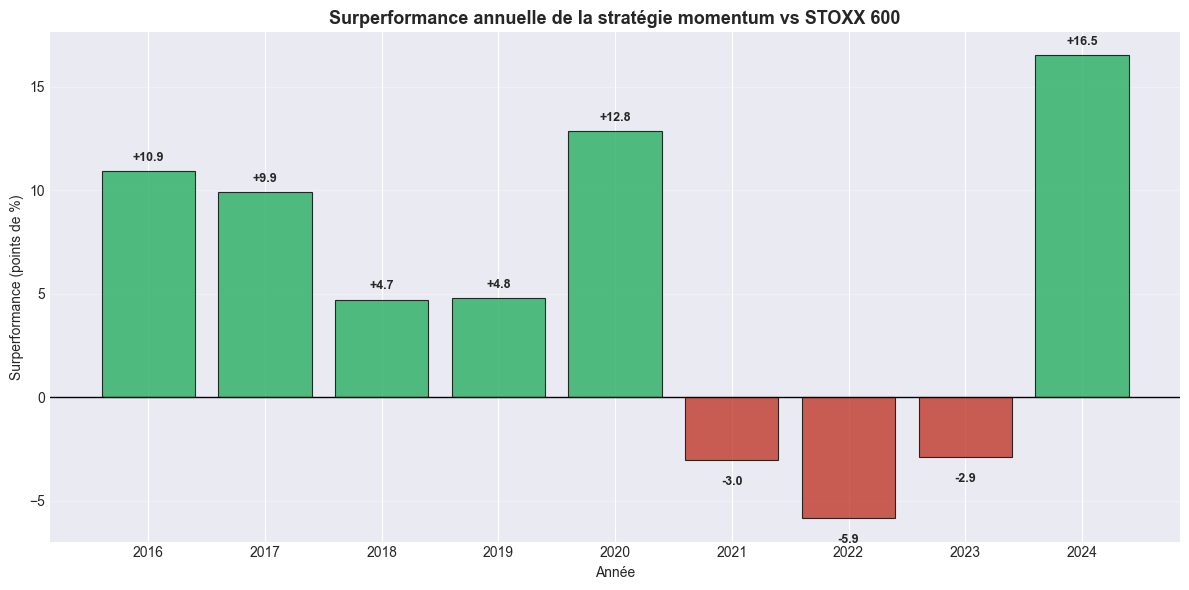

Graphique sauvegardé.


In [11]:
# Graphique en barres : surperformance annuelle
fig, ax = plt.subplots(figsize=(12, 6))

years = annual_comp.index.astype(str)
surperf = annual_comp["Surperformance"].values
colors = ["#27ae60" if x > 0 else "#c0392b" for x in surperf]

bars = ax.bar(years, surperf, color=colors, alpha=0.8, edgecolor="black", linewidth=0.8)

ax.axhline(0, color="black", linewidth=1)
ax.set_title("Surperformance annuelle de la stratégie momentum vs STOXX 600",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Année")
ax.set_ylabel("Surperformance (points de %)")
ax.grid(True, alpha=0.3, axis="y")

# Annoter les valeurs
for bar, val in zip(bars, surperf):
    ax.text(bar.get_x() + bar.get_width()/2,
            val + (0.5 if val > 0 else -1.2),
            f"{val:+.1f}", ha="center", fontsize=9, fontweight="bold")

plt.tight_layout()
plt.savefig(FIGURES / "04_surperformance_annuelle.png", dpi=150, bbox_inches="tight")
plt.show()

print("Graphique sauvegardé.")

### Décomposition de la performance par année

La surperformance globale masque une dynamique annuelle contrastée. La stratégie bat le benchmark 6 années sur 9 (taux de réussite de 67 %).

**Une surperformance concentrée en régime de marché normal**  
La stratégie domine nettement le marché lors des années 2016-2020 et 2024, avec des surperformances allant de +4,7 à +16,5 points. Elle se distingue 
particulièrement en 2020 (+12,8 points), année du choc Covid, et en 2024 (+16,5 points). Elle résiste également mieux que le marché en phase baissière, comme en 2018 (−6,3 % contre −11,0 % pour le benchmark).

**Des sous-performances concentrées sur 2021-2023**  
Les trois seules années de sous-performance sont consécutives : 2021 (−3,0 pts), 2022 (−5,9 pts) et 2023 (−2,9 pts). Cette concentration n'est pas fortuite. Elle correspond à la phase de rotation de marché provoquée par le resserrement 
monétaire : 
- en 2021, le rebond généralisé post-Covid (« rallye de tout ») a favorisé le 
  marché large au détriment d'une sélection momentum ; 
- en 2022-2023, la hausse des taux a déclenché une rotation des titres de 
  croissance (surreprésentés dans le portefeuille momentum) vers les titres value.

**Interprétation**  
Ce profil est caractéristique du facteur momentum : il performe en régime de marché établi, où les tendances persistent, mais souffre lors des retournements de régime, où les leaders changent brutalement. La régularité de la surperformance hors période de rotation (6 années sur 6 entre 2016-2020 et 2024) confirme la solidité du signal, tandis que la séquence 2021-2023 en délimite clairement les conditions de faiblesse. Cette lecture conditionnelle est plus informative qu'une moyenne globale et souligne l'intérêt d'un éventuel filtre de régime de marché comme extension.

## Conclusion du notebook 04

Ce notebook a approfondi l'analyse de la stratégie momentum à travers trois axes complémentaires.

### Comparaison au facteur momentum académique

Une régression des rendements de la stratégie sur le marché et le facteur WML de Ken French révèle une exposition significative au momentum (beta WML = 0,47, p < 0,001) une fois le risque de marché neutralisé. L'alpha résiduel n'étant pas significatif, la surperformance s'explique entièrement par l'exposition au facteur momentum : la stratégie capture donc bien le phénomène documenté par la littérature, sans effet inexpliqué.

### Robustesse à la fenêtre de calcul

Les trois fenêtres testées (3, 6 et 12 mois) surperforment toutes le benchmark, avec une hiérarchie conforme à la littérature (les fenêtres moyennes de 6-12 mois dominent la fenêtre courte de 3 mois). Ce résultat écarte largement le risque de data snooping : la surperformance ne dépend pas d'un choix de paramètre arbitraire.

### Régularité de la performance

La stratégie bat le marché 6 années sur 9. Ses sous-performances sont concentrées sur la période de rotation de marché 2021-2023 (resserrement monétaire), conformément au comportement attendu du momentum lors des retournements de régime. Hors de cette période, la surperformance est régulière et substantielle.

### Synthèse

Les trois analyses convergent vers une conclusion cohérente : la stratégie capture un facteur momentum robuste et reconnu, dont la performance est régulière en régime de marché normal mais vulnérable aux rotations brutales. Combinée à la réserve méthodologique sur le biais de survie (notebook 03), cette analyse fournit une évaluation honnête et nuancée de la stratégie.

### Prochaine étape

Notebook 05 : extension par apprentissage automatique — construction d'un modèle prédictif du ranking des titres et comparaison à la règle momentum naïve.